In [1]:
%pip install polars scikit-learn matplotlib seaborn scipy umap-learn

In [2]:
from pathlib import Path
import polars as pl

# Target path
dataset_path = Path("data/lanl-auth/lanl-auth-dataset-1-00")


lf = pl.scan_csv(dataset_path, separator=",", infer_schema_length=10000, has_header=False)

# Materialize once for EDA (limit rows if needed for very large data)
df = lf.collect(streaming=True)

print("=== BASIC INFO ===")
print(f"Rows: {df.height:,}")
print(f"Columns: {df.width}")
print("\nSchema:")
print(df.schema)

df.columns = ["time", "user", "computer"]

print("\n=== HEAD ===")
print(df.head(10))

print("\n=== NULL COUNTS ===")
print(df.null_count())

print("\n=== UNIQUE COUNTS (per column) ===")
unique_counts = df.select([pl.col(c).n_unique().alias(c) for c in df.columns])
print(unique_counts)


/tmp/ipykernel_1835/453599353.py:11: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  df = lf.collect(streaming=True)


FileNotFoundError: No such file or directory (os error 2): data/lanl-auth/lanl-auth-dataset-1-00

This error occurred with the following context stack:
	[1] 'csv scan'
	[2] 'sink'


In [ ]:

for col in df.columns:
    print(f"\n=== TOP VALUES FOR {col} ===")
    top_values = df.select(pl.col(col)).group_by(col).count().sort("count", descending=True).head(10)
    print(top_values)


=== TOP VALUES FOR time ===


/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_5655/1272031904.py:3: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  top_values = df.select(pl.col(col)).group_by(col).count().sort("count", descending=True).head(10)


shape: (10, 2)
┌─────────┬───────┐
│ time    ┆ count │
│ ---     ┆ ---   │
│ i64     ┆ u32   │
╞═════════╪═══════╡
│ 112928  ┆ 1025  │
│ 112929  ┆ 801   │
│ 112932  ┆ 707   │
│ 522057  ┆ 702   │
│ 2336457 ┆ 701   │
│ 1126857 ┆ 700   │
│ 1731663 ┆ 680   │
│ 2336456 ┆ 665   │
│ 1126859 ┆ 660   │
│ 922305  ┆ 657   │
└─────────┴───────┘

=== TOP VALUES FOR user ===
shape: (10, 2)
┌───────┬─────────┐
│ user  ┆ count   │
│ ---   ┆ ---     │
│ str   ┆ u32     │
╞═══════╪═════════╡
│ U12   ┆ 2676710 │
│ U13   ┆ 1194429 │
│ U128  ┆ 900805  │
│ U4148 ┆ 796339  │
│ U60   ┆ 696906  │
│ U112  ┆ 656954  │
│ U77   ┆ 596461  │
│ U124  ┆ 571272  │
│ U438  ┆ 513249  │
│ U156  ┆ 487611  │
└───────┴─────────┘

=== TOP VALUES FOR computer ===
shape: (10, 2)
┌──────────┬─────────┐
│ computer ┆ count   │
│ ---      ┆ ---     │
│ str      ┆ u32     │
╞══════════╪═════════╡
│ C148     ┆ 2377727 │
│ C219     ┆ 1548622 │
│ C151     ┆ 1441769 │
│ C200     ┆ 1376372 │
│ C248     ┆ 1118359 │
│ C154     ┆ 797700  │


Explained variance ratio: [0.10358188 0.09867263]
Total explained variance: 0.2022545056630377


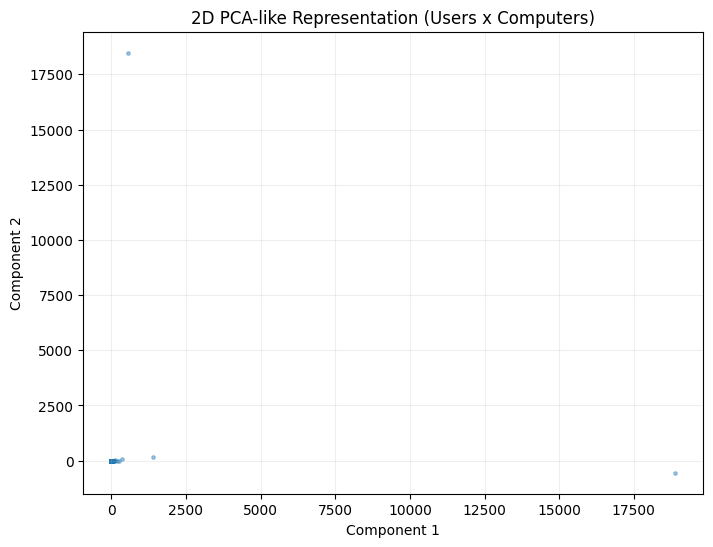

In [ ]:
import numpy as np
from scipy.sparse import coo_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# Use a sample for memory safety on very large data
sample_n = min(2_000_000, df.height)
sampled = df.sample(n=sample_n, shuffle=True, seed=42)

# Encode categories as integer ids
sampled = sampled.with_columns(
    [
        pl.col("user").cast(pl.Categorical).to_physical().alias("user_id"),
        pl.col("computer").cast(pl.Categorical).to_physical().alias("computer_id"),
    ]
)

# Build user-computer interaction counts
pairs = (
    sampled.group_by(["user_id", "computer_id"])
    .len()
    .rename({"len": "cnt"})
)

u = pairs["user_id"].to_numpy()
c = pairs["computer_id"].to_numpy()
v = pairs["cnt"].to_numpy()

n_users = int(sampled["user_id"].max()) + 1
n_computers = int(sampled["computer_id"].max()) + 1

X = coo_matrix((v, (u, c)), shape=(n_users, n_computers)).tocsr()

# PCA-like 2D projection for sparse matrix
svd = TruncatedSVD(n_components=2, random_state=42)
Z = svd.fit_transform(X)

print("Explained variance ratio:", svd.explained_variance_ratio_)
print("Total explained variance:", svd.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
plt.scatter(Z[:, 0], Z[:, 1], s=6, alpha=0.4)
plt.title("2D PCA-like Representation (Users x Computers)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(alpha=0.2)
plt.show()

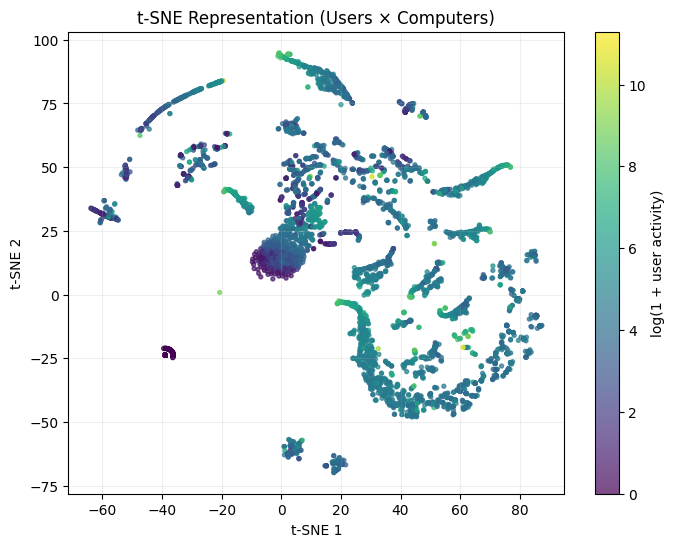

In [ ]:
from sklearn.manifold import TSNE

# t-SNE is expensive; use a reproducible subset of users
n_tsne = min(12000, X.shape[0])
rng = np.random.default_rng(42)
idx = rng.choice(X.shape[0], size=n_tsne, replace=False)

X_sub = X[idx]

# Pre-reduce sparse high-dimensional data before t-SNE
X_sub_50 = TruncatedSVD(n_components=50, random_state=42).fit_transform(X_sub)

tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=30,
    max_iter=1000,
    random_state=42,
)

Z_tsne = tsne.fit_transform(X_sub_50)

# Optional coloring by activity (total auth count per user in subset)
activity = np.asarray(X_sub.sum(axis=1)).ravel()

plt.figure(figsize=(8, 6))
sc = plt.scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=np.log1p(activity), s=8, alpha=0.7, cmap="viridis")
plt.colorbar(sc, label="log(1 + user activity)")
plt.title("t-SNE Representation (Users × Computers)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(alpha=0.2)
plt.show()

/Users/mpersson/COMP9150/proj2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mpersson/COMP9150/proj2/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


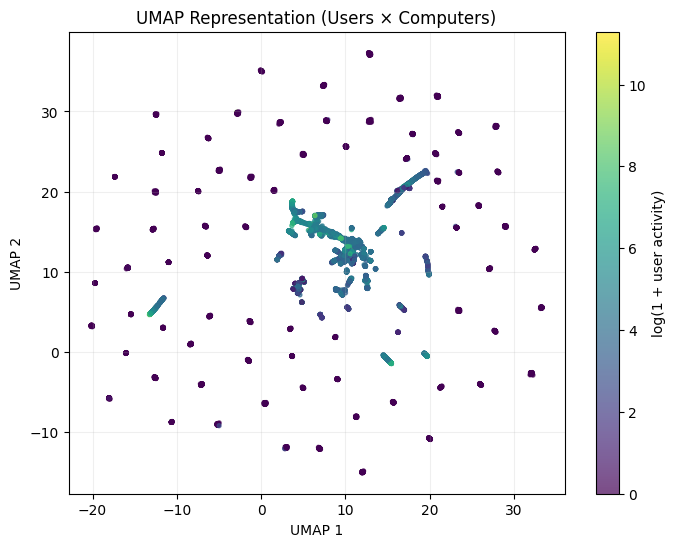

In [ ]:
# UMAP on the same pre-reduced subset used for t-SNE (X_sub_50)
try:
    import umap.umap_ as umap
except ImportError:
    raise ImportError("UMAP is not installed. Run: %pip install umap-learn")

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
)

Z_umap = umap_model.fit_transform(X_sub_50)

plt.figure(figsize=(8, 6))
sc_umap = plt.scatter(
    Z_umap[:, 0],
    Z_umap[:, 1],
    c=np.log1p(activity),
    s=8,
    alpha=0.7,
    cmap="viridis",
)
plt.colorbar(sc_umap, label="log(1 + user activity)")
plt.title("UMAP Representation (Users × Computers)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(alpha=0.2)
plt.show()

Cluster sizes: [11993     1     1     1     1     1     1     1]


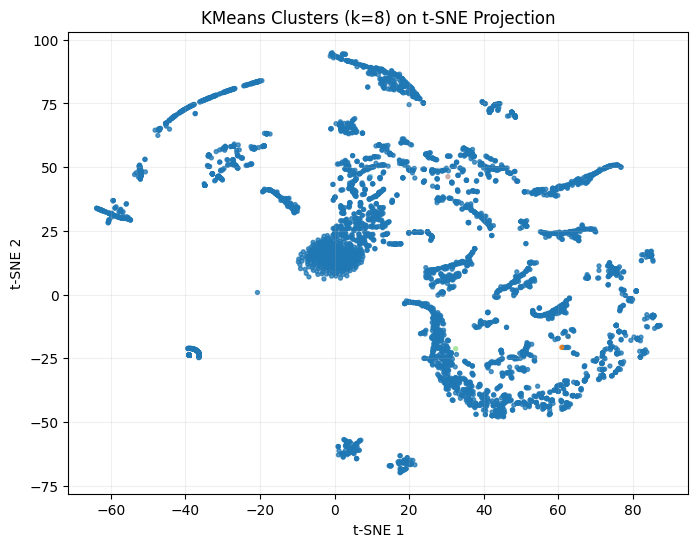

In [ ]:
from sklearn.cluster import KMeans

# Choose number of clusters
k = 8

# Fit KMeans on the 50D SVD features of the subset
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X_sub_50)

# Quick cluster size summary
cluster_sizes = np.bincount(cluster_labels)
print("Cluster sizes:", cluster_sizes)

# Visualize clusters on existing t-SNE embedding
plt.figure(figsize=(8, 6))
plt.scatter(
    Z_tsne[:, 0],
    Z_tsne[:, 1],
    c=cluster_labels,
    s=8,
    alpha=0.75,
    cmap="tab20",
)
plt.title(f"KMeans Clusters (k={k}) on t-SNE Projection")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(alpha=0.2)
plt.show()

Estimated clusters: 7
Noise points: 1430
Label counts: {-1: 1430, 0: 10476, 1: 10, 2: 38, 3: 7, 4: 19, 5: 10, 6: 10}


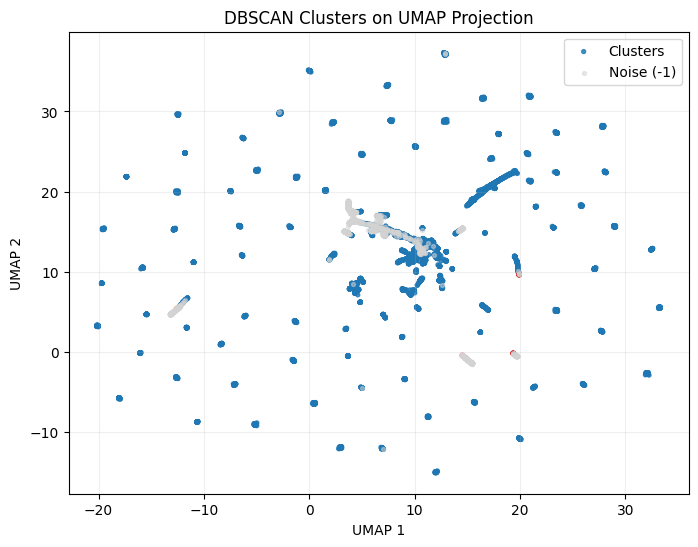

In [ ]:
from sklearn.cluster import DBSCAN

# DBSCAN on the 50D SVD features
dbscan = DBSCAN(eps=1.5, min_samples=10, metric="euclidean", n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_sub_50)

# Summary
n_noise = int((dbscan_labels == -1).sum())
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"Estimated clusters: {n_clusters}")
print(f"Noise points: {n_noise}")

labels_unique, counts = np.unique(dbscan_labels, return_counts=True)
print("Label counts:", dict(zip(labels_unique.tolist(), counts.tolist())))

# Visualize on existing UMAP embedding
plt.figure(figsize=(8, 6))
noise_mask = dbscan_labels == -1
core_mask = ~noise_mask

if core_mask.any():
    plt.scatter(
        Z_umap[core_mask, 0],
        Z_umap[core_mask, 1],
        c=dbscan_labels[core_mask],
        s=8,
        alpha=0.8,
        cmap="tab20",
        label="Clusters",
    )

if noise_mask.any():
    plt.scatter(
        Z_umap[noise_mask, 0],
        Z_umap[noise_mask, 1],
        c="lightgray",
        s=8,
        alpha=0.5,
        label="Noise (-1)",
    )

plt.title("DBSCAN Clusters on UMAP Projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(alpha=0.2)
plt.legend(loc="best")
plt.show()

Hierarchical cluster sizes: {0: 2993, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1}


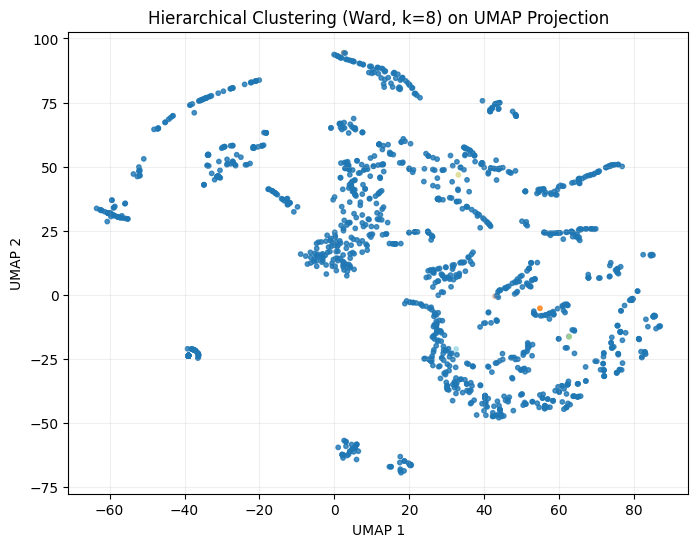

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Hierarchical clustering can be expensive; use a manageable subset
n_hier = min(3000, X_sub_50.shape[0])
hier_idx = rng.choice(X_sub_50.shape[0], size=n_hier, replace=False)

X_hier = X_sub_50[hier_idx]
Z_hier = Z_tsne[hier_idx]

# Use existing k from previous cells
hier = AgglomerativeClustering(n_clusters=k, linkage="ward")
hier_labels = hier.fit_predict(X_hier)

# Summary
labels, counts = np.unique(hier_labels, return_counts=True)
print("Hierarchical cluster sizes:", dict(zip(labels.tolist(), counts.tolist())))

# Visualize on UMAP space
plt.figure(figsize=(8, 6))
plt.scatter(
    Z_hier[:, 0],
    Z_hier[:, 1],
    c=hier_labels,
    s=10,
    alpha=0.8,
    cmap="tab20",
)
plt.title(f"Hierarchical Clustering (Ward, k={k}) on UMAP Projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(alpha=0.2)
plt.show()

Detected anomalies: 337 / 12000

Top anomaly candidates (local_idx, original_user_idx, score, activity):
 8589 |   1334 | -0.800042 | 2765
10706 |     94 | -0.794846 | 3638
 7601 |   1243 | -0.790404 | 2467
 1254 |    346 | -0.790254 | 2214
  739 |   2607 | -0.787622 | 2427
 8184 |   1320 | -0.787395 | 2502
 5074 |    102 | -0.776397 | 2131
 5845 |    113 | -0.770590 | 2805
10199 |   1163 | -0.763255 | 2036
 7145 |    964 | -0.756820 | 2775
 1688 |     44 | -0.756059 | 3888
 3843 |    821 | -0.755174 | 3319
11210 |    263 | -0.754666 | 3306
 1263 |    501 | -0.754078 | 3029
 7373 |     53 | -0.751603 | 3211
11757 |   2079 | -0.749822 | 1546
10763 |     98 | -0.749471 | 2783
 1363 |    414 | -0.748506 | 1711
 2875 |    125 | -0.748328 | 1803
 8148 |    843 | -0.748323 | 3421


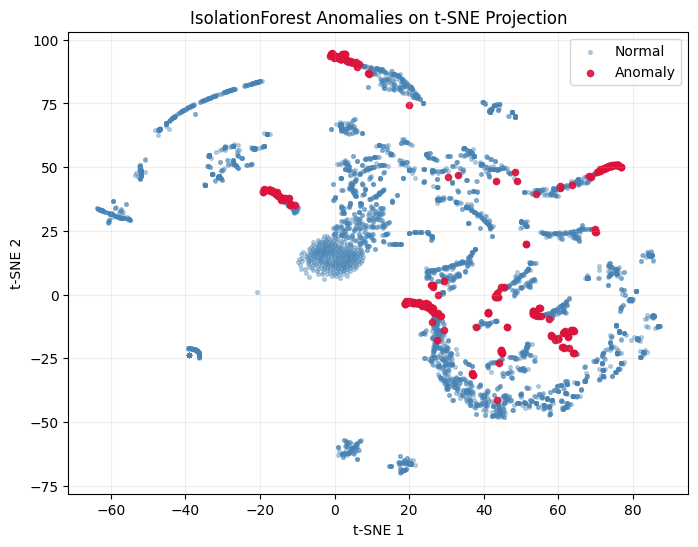

In [ ]:
from sklearn.ensemble import IsolationForest

# Isolation "tree" model (IsolationForest)
iso = IsolationForest(
	n_estimators=300,
	contamination='auto',   # expected anomaly fraction
	random_state=42,
	n_jobs=-1,
)

iso_labels = iso.fit_predict(X_sub_50)          # 1 = normal, -1 = anomaly
iso_scores = iso.score_samples(X_sub_50)        # lower = more anomalous
iso_anomaly_mask = iso_labels == -1

print(f"Detected anomalies: {iso_anomaly_mask.sum()} / {len(iso_labels)}")

# Show most anomalous points
top_n = 20
top_local_idx = np.argsort(iso_scores)[:top_n]  # smallest scores first
print("\nTop anomaly candidates (local_idx, original_user_idx, score, activity):")
for i in top_local_idx:
	print(
		f"{i:5d} | {int(idx[i]):6d} | {iso_scores[i]: .6f} | {int(activity[i])}"
	)

# Visualize on existing t-SNE embedding
plt.figure(figsize=(8, 6))
plt.scatter(
	Z_tsne[~iso_anomaly_mask, 0],
	Z_tsne[~iso_anomaly_mask, 1],
	s=7,
	alpha=0.35,
	c="steelblue",
	label="Normal",
)
plt.scatter(
	Z_tsne[iso_anomaly_mask, 0],
	Z_tsne[iso_anomaly_mask, 1],
	s=20,
	alpha=0.9,
	c="crimson",
	label="Anomaly",
)
plt.title("IsolationForest Anomalies on t-SNE Projection")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(loc="best")
plt.grid(alpha=0.2)
plt.show()

Top anomalous local index: 8589
Top anomalous user_id: 1334
Top anomalous user label: U226


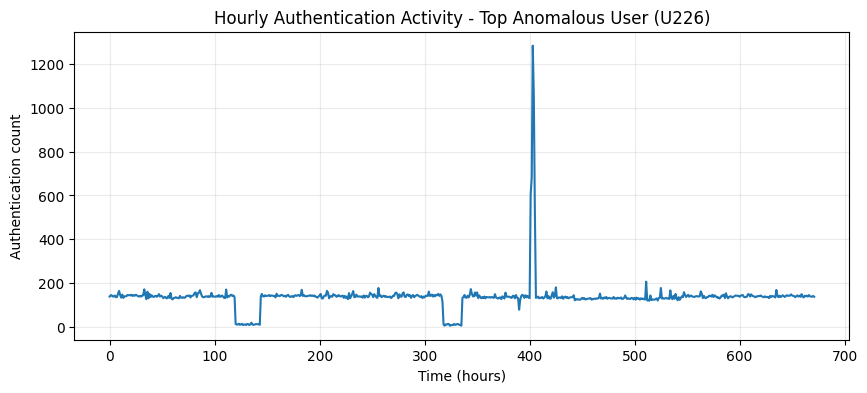

In [ ]:
# Top anomalous user in the t-SNE/IsolationForest subset
top_local = int(top_local_idx[0])  # most anomalous local index
top_user_id = int(idx[top_local])  # corresponding user_id row in X

# Map user_id -> original user label
user_map = sampled.select(["user_id", "user"]).unique(subset=["user_id"])
top_user = user_map.filter(pl.col("user_id") == top_user_id).select("user").to_series()[0]

print(f"Top anomalous local index: {top_local}")
print(f"Top anomalous user_id: {top_user_id}")
print(f"Top anomalous user label: {top_user}")

# Build time-binned activity from the original full dataframe
bin_size_sec = 3600  # 1 hour bins
user_activity = (
    df.filter(pl.col("user") == top_user)
    .with_columns(((pl.col("time") // bin_size_sec) * bin_size_sec).alias("time_bin"))
    .group_by("time_bin")
    .len()
    .rename({"len": "auth_count"})
    .sort("time_bin")
)

# Plot
if user_activity.height == 0:
    print("No activity found for the selected user in original data.")
else:
    t_hours = user_activity["time_bin"].to_numpy() / 3600.0
    counts = user_activity["auth_count"].to_numpy()

    plt.figure(figsize=(10, 4))
    plt.plot(t_hours, counts, linewidth=1.5)
    plt.title(f"Hourly Authentication Activity - Top Anomalous User ({top_user})")
    plt.xlabel("Time (hours)")
    plt.ylabel("Authentication count")
    plt.grid(alpha=0.25)
    plt.show()

Top anomalous user: U226
Total unique computers accessed: 10
shape: (10, 2)
┌──────────┬────────────┐
│ computer ┆ auth_count │
│ ---      ┆ ---        │
│ str      ┆ u32        │
╞══════════╪════════════╡
│ C306     ┆ 51185      │
│ C151     ┆ 20853      │
│ C200     ┆ 17179      │
│ C670     ┆ 1722       │
│ C150     ┆ 573        │
│ C443     ┆ 184        │
│ C115     ┆ 43         │
│ C134     ┆ 18         │
│ C14682   ┆ 10         │
│ C135     ┆ 5          │
└──────────┴────────────┘


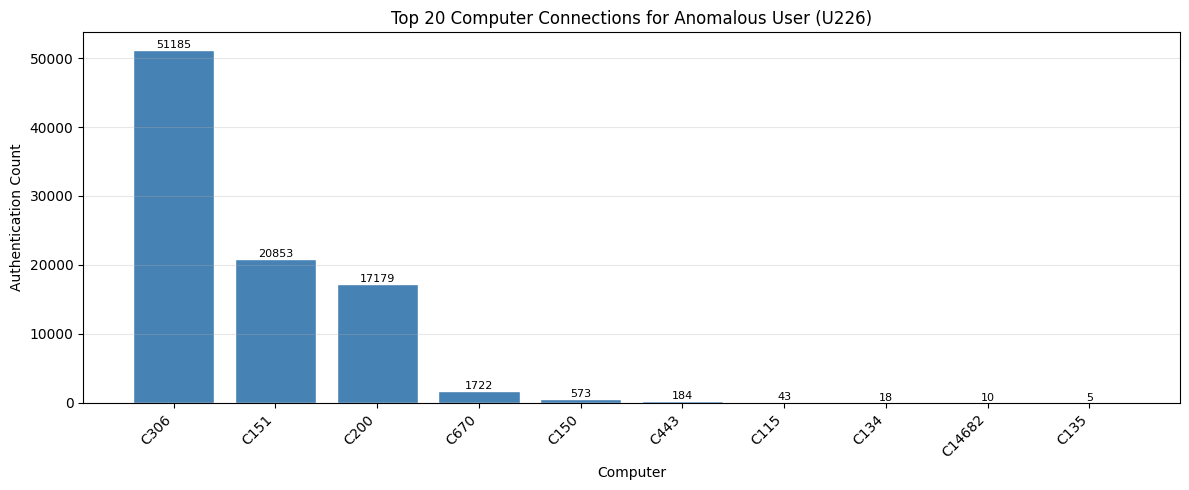

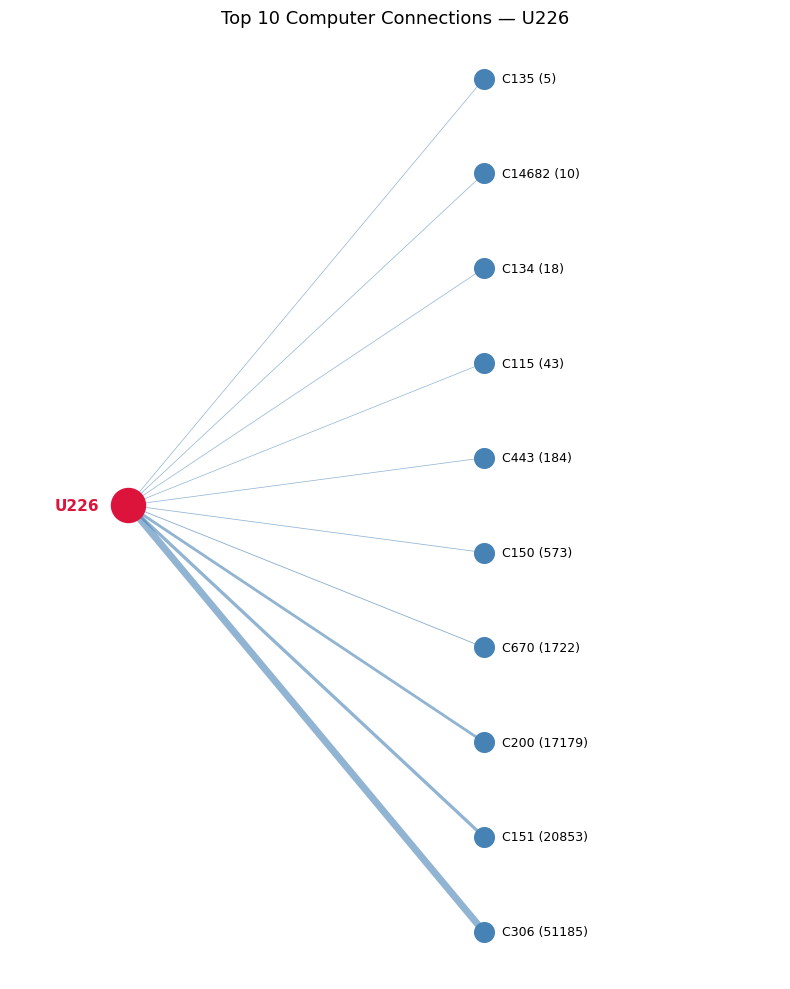

In [ ]:
# Get all computers accessed by the top anomalous user
top_user_connections = (
    df.filter(pl.col("user") == top_user)
    .group_by("computer")
    .len()
    .rename({"len": "auth_count"})
    .sort("auth_count", descending=True)
)

print(f"Top anomalous user: {top_user}")
print(f"Total unique computers accessed: {top_user_connections.height}")
print(top_user_connections.head(20))

# Plot top N connections
top_n_connections = 20
top_conn = top_user_connections.head(top_n_connections)

computers = top_conn["computer"].to_list()
auth_counts = top_conn["auth_count"].to_numpy()

plt.figure(figsize=(12, 5))
bars = plt.bar(computers, auth_counts, color="steelblue", edgecolor="white")
plt.title(f"Top {top_n_connections} Computer Connections for Anomalous User ({top_user})")
plt.xlabel("Computer")
plt.ylabel("Authentication Count")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

# Annotate bars
for bar, count in zip(bars, auth_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(count),
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

# Network-style bipartite visualization
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 10))

top_n_net = min(15, top_user_connections.height)
net_conn = top_user_connections.head(top_n_net)
net_computers = net_conn["computer"].to_list()
net_counts = net_conn["auth_count"].to_numpy()
max_count = net_counts.max()

# User node on the left, computers on the right
user_x, user_y = 0.2, 0.5
comp_x = 0.8
comp_ys = np.linspace(0.05, 0.95, top_n_net)

ax.scatter([user_x], [user_y], s=600, c="crimson", zorder=5)
ax.text(user_x - 0.05, user_y, top_user, ha="right", va="center", fontsize=11, fontweight="bold", color="crimson")

for cy, comp, cnt in zip(comp_ys, net_computers, net_counts):
    lw = 0.5 + 4.5 * (cnt / max_count)
    ax.plot([user_x, comp_x], [user_y, cy], "steelblue", linewidth=lw, alpha=0.6)
    ax.scatter([comp_x], [cy], s=200, c="steelblue", zorder=5)
    ax.text(comp_x + 0.03, cy, f"{comp} ({cnt})", va="center", fontsize=9)

ax.set_xlim(0, 1.3)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title(f"Top {top_n_net} Computer Connections — {top_user}", fontsize=13)
plt.tight_layout()
plt.show()